In [1]:
import pandas
import numpy
import utils

In [2]:
df = pandas.read_csv('../data/survey2024_headersandcommascleaned_recleaned.csv')

In [3]:
short_colnames = {'grants you apply for':'grants\n(mine)',
                  'grants someone else applies for':'grants\n(others\')',
                  'internal granted funding':'internal',
                  'recharge for consulting':'consulting',
                  'recharge on image analysis projects data analysis as a service':'analysis\nprojects',
                  'recharge on other services eg microscope time':'microscope\nfees',
                  'I don\'t know':"I don\'t\nknow"}
long_colnames = {f'Q5 If you work in a facility how much of your budget comes from each of these Please do not answer if you do not work in a facility ({k})':v for k,v in short_colnames.items()}
long_colnames_for_spreadsheet = {f'Q5 If you work in a facility how much of your budget comes from each of these Please do not answer if you do not work in a facility ({k})':v.replace('\n',' ') for k,v in short_colnames.items()}

utils.normalized_percent_graphs(df,long_colnames,'../figures/FundingSources.png',cmap='Blues')

In [4]:
df_subset = df[[x for x in long_colnames.keys()]]
df_subset.replace({'':numpy.NaN,'0%':numpy.NaN,'0-25%':0.25,'25-50%':0.5,'50-75%':0.75,'75-100%':1,},inplace=True)
df_subset.dropna(how="all",inplace=True)
print(df_subset.shape)
df_subset.fillna(0,inplace=True)
df_subset.rename(columns=long_colnames_for_spreadsheet,inplace=True)
df_subset.to_csv('funding_percent.csv')


(155, 7)


/var/folders/8t/hj0jrcld7sjbfvg6svqpwggr0000gq/T/ipykernel_73341/361569583.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset.replace({'':numpy.NaN,'0%':numpy.NaN,'0-25%':0.25,'25-50%':0.5,'50-75%':0.75,'75-100%':1,},inplace=True)
/var/folders/8t/hj0jrcld7sjbfvg6svqpwggr0000gq/T/ipykernel_73341/361569583.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset.dropna(how="all",inplace=True)
/var/folders/8t/hj0jrcld7sjbfvg6svqpwggr0000gq/T/ipykernel_73341/361569583.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https

For n_clusters = 2 The average silhouette_score is : 0.2087230540882395
For n_clusters = 3 The average silhouette_score is : 0.3239807733356616
For n_clusters = 4 The average silhouette_score is : 0.34136118001392834
For n_clusters = 5 The average silhouette_score is : 0.34042180630536356
For n_clusters = 6 The average silhouette_score is : 0.3567197215447823
For n_clusters = 7 The average silhouette_score is : 0.34939696684852173
For n_clusters = 8 The average silhouette_score is : 0.33183007171070616
For n_clusters = 9 The average silhouette_score is : 0.3178888927743302
For n_clusters = 10 The average silhouette_score is : 0.32852020557014217


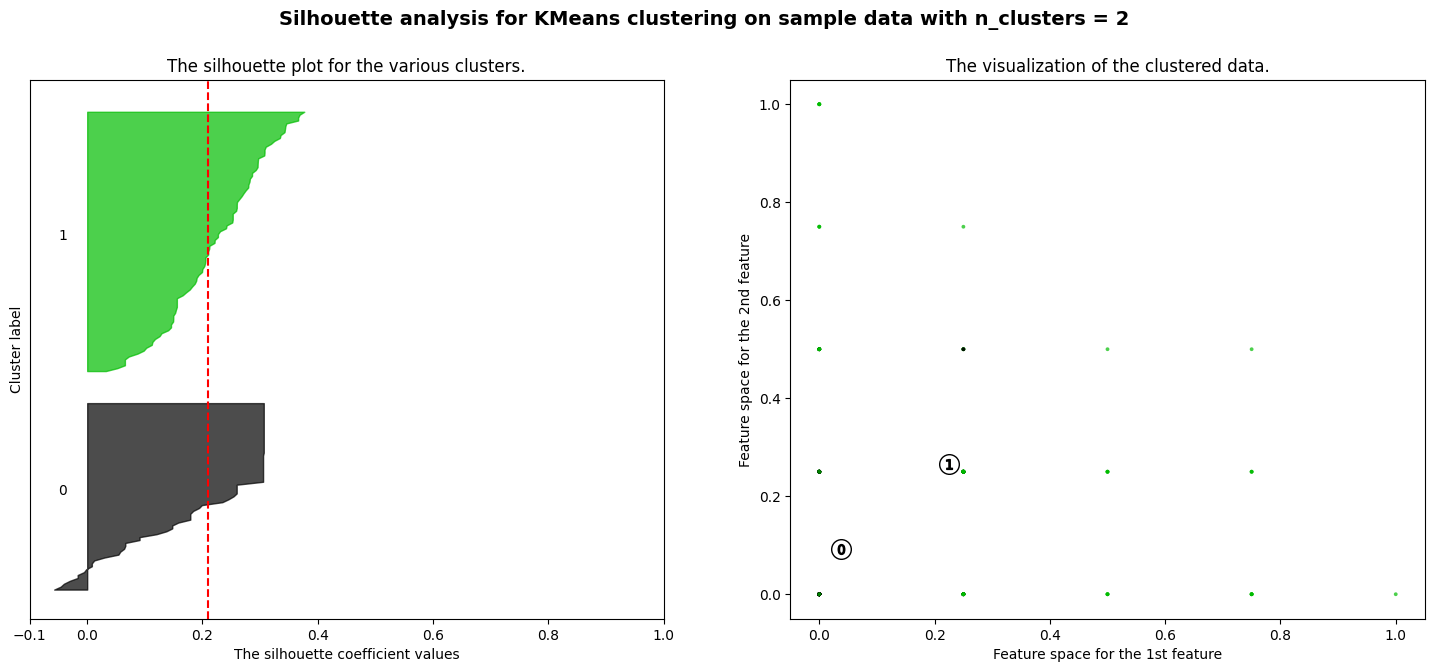

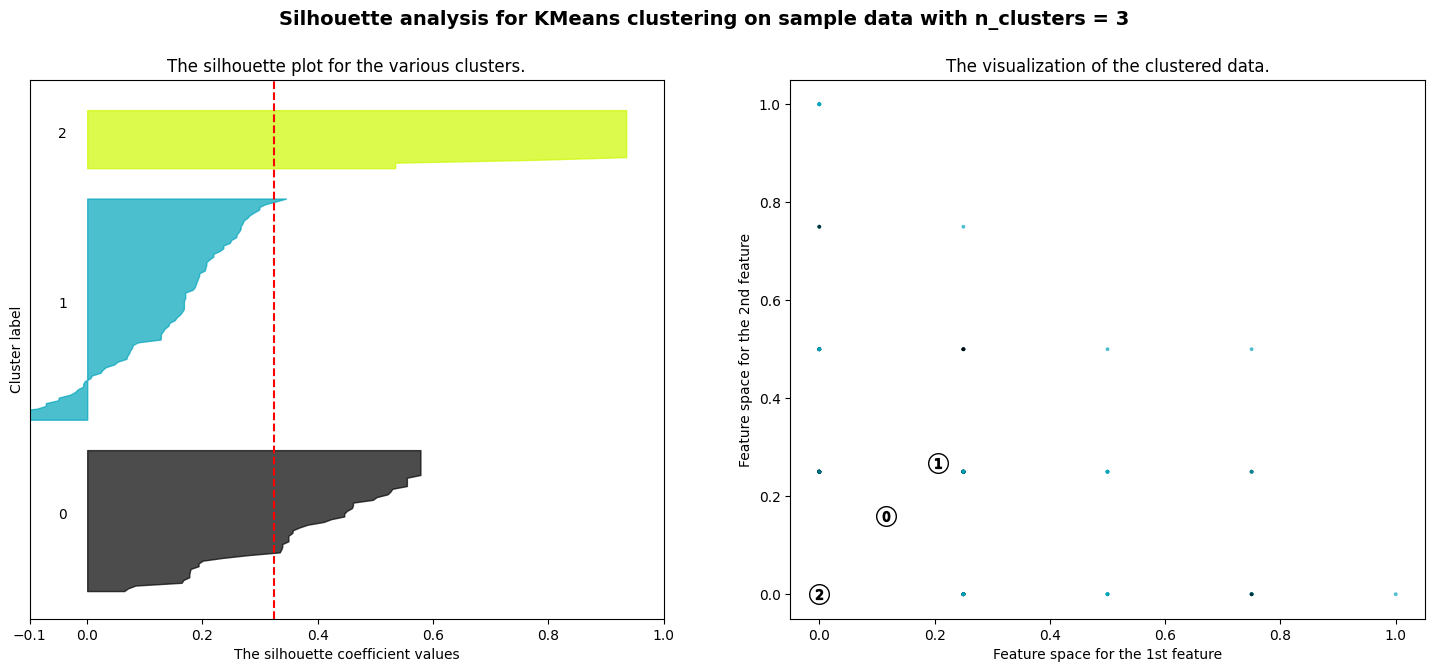

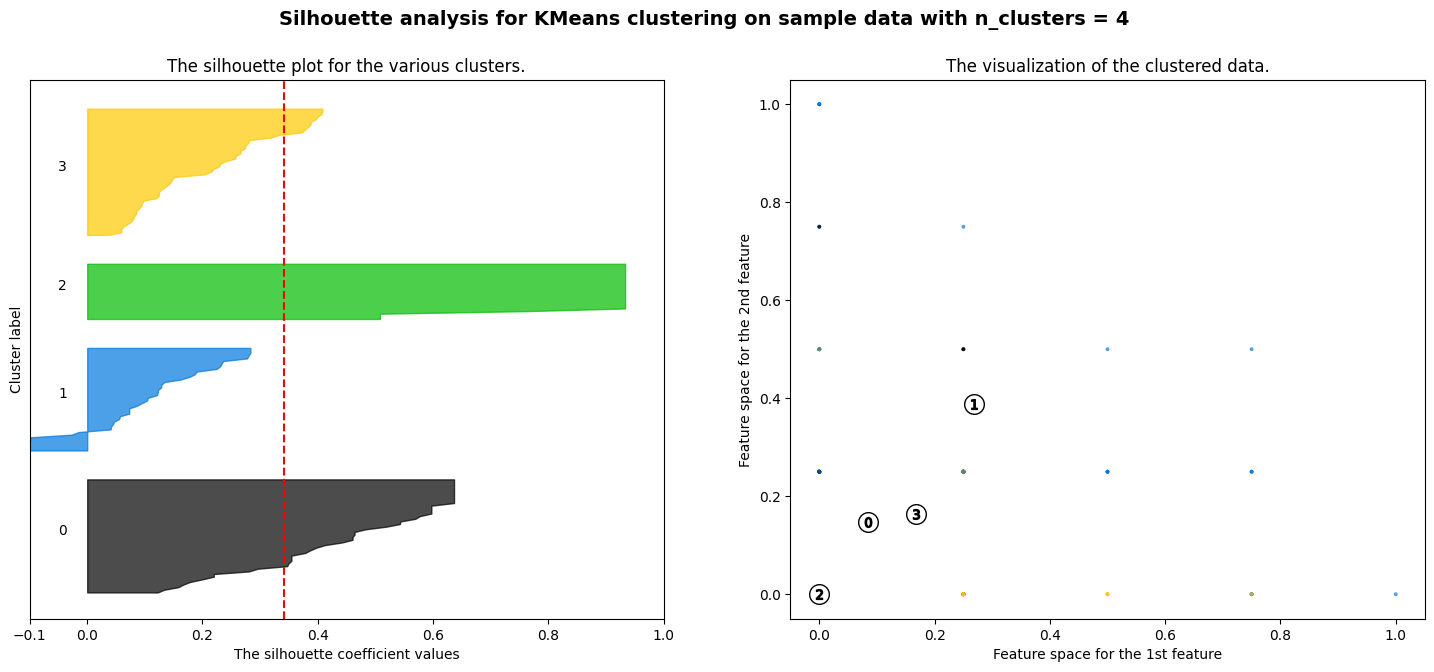

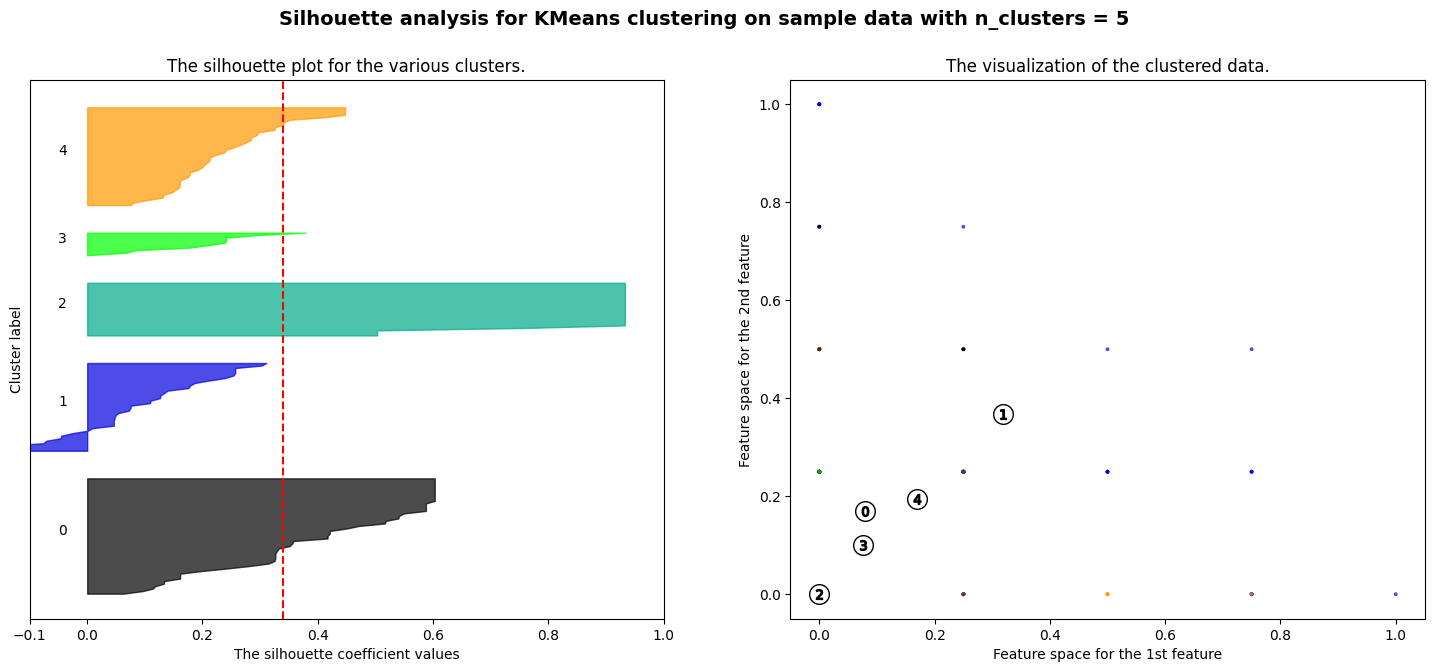

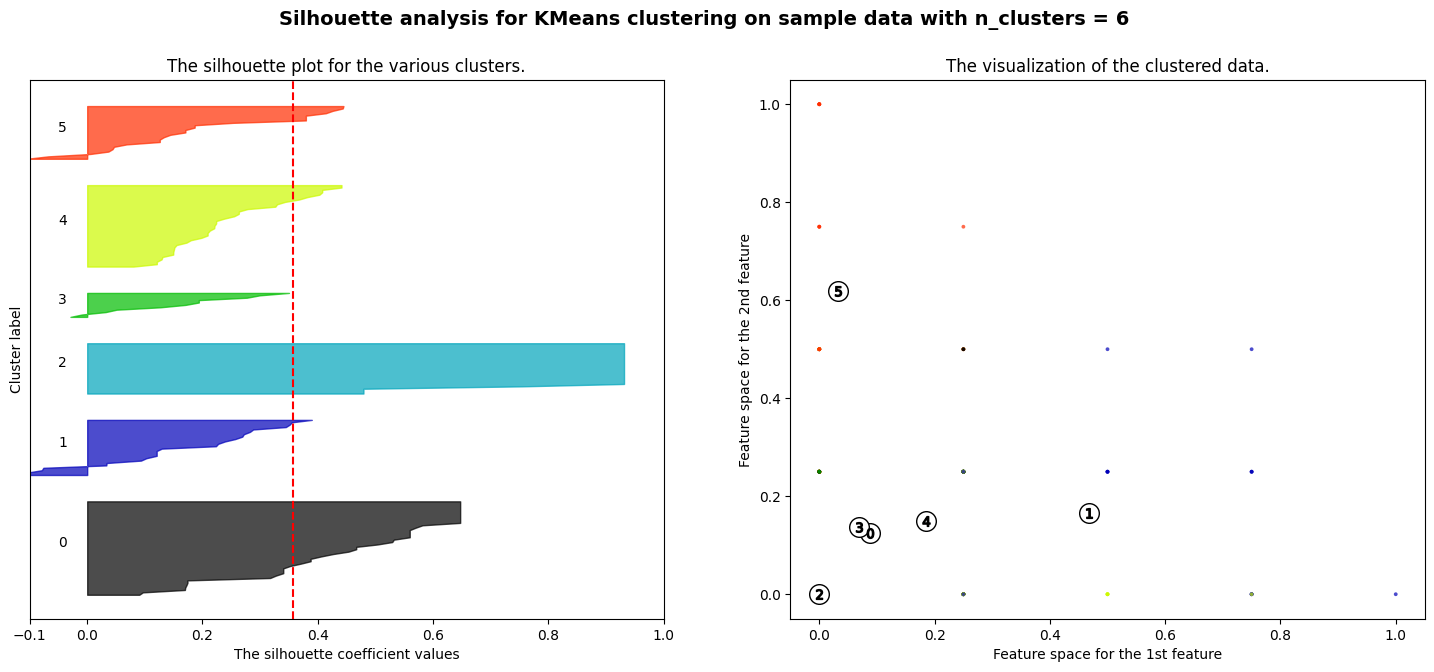

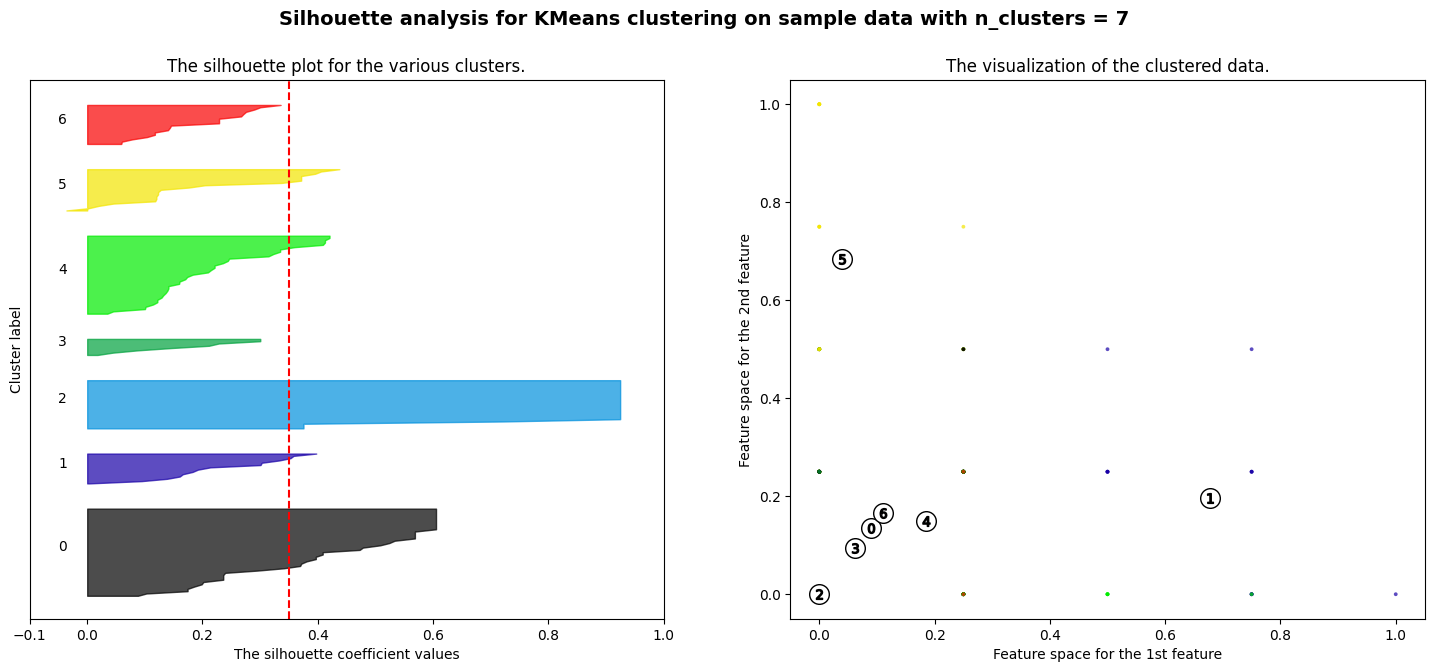

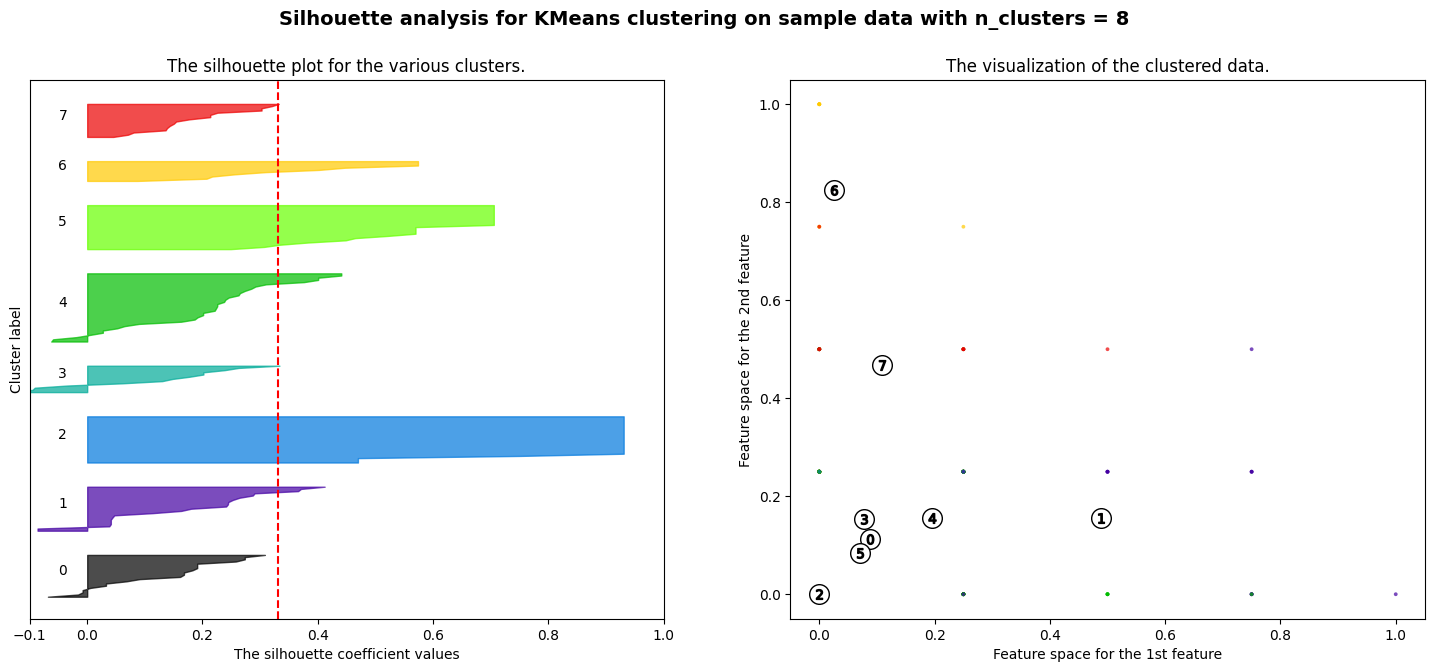

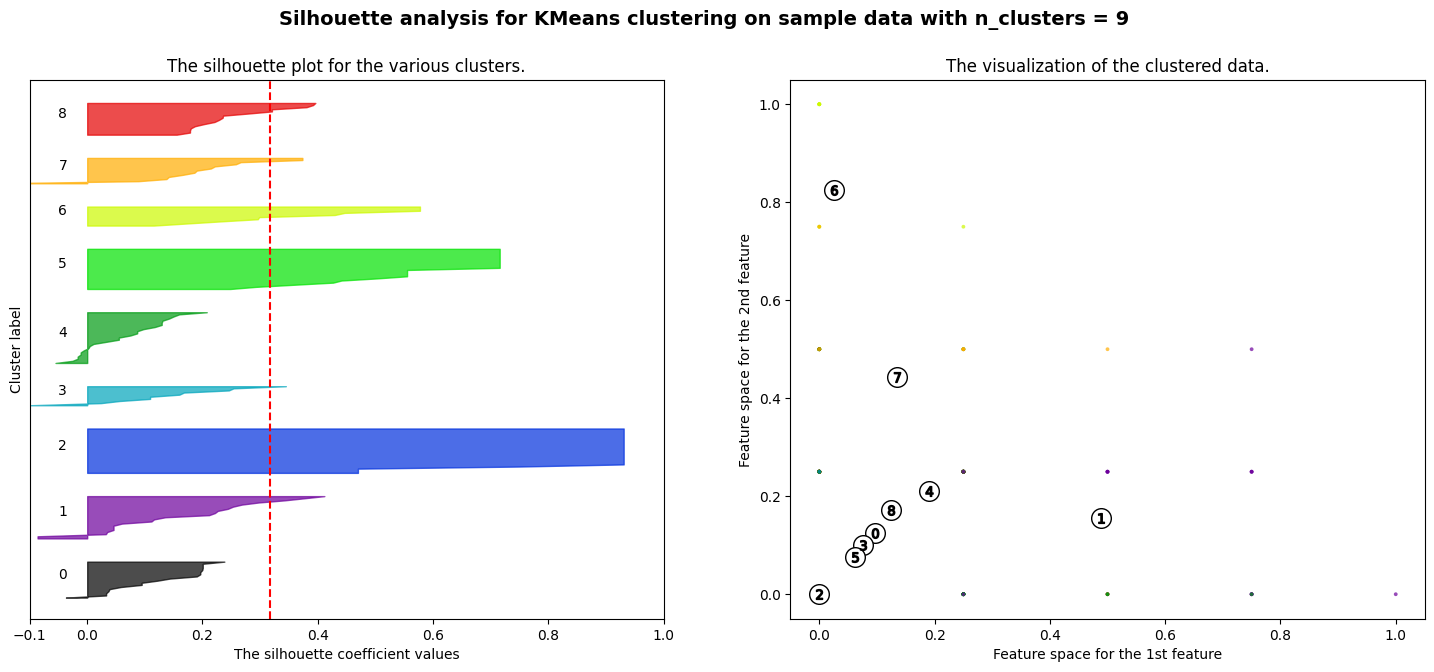

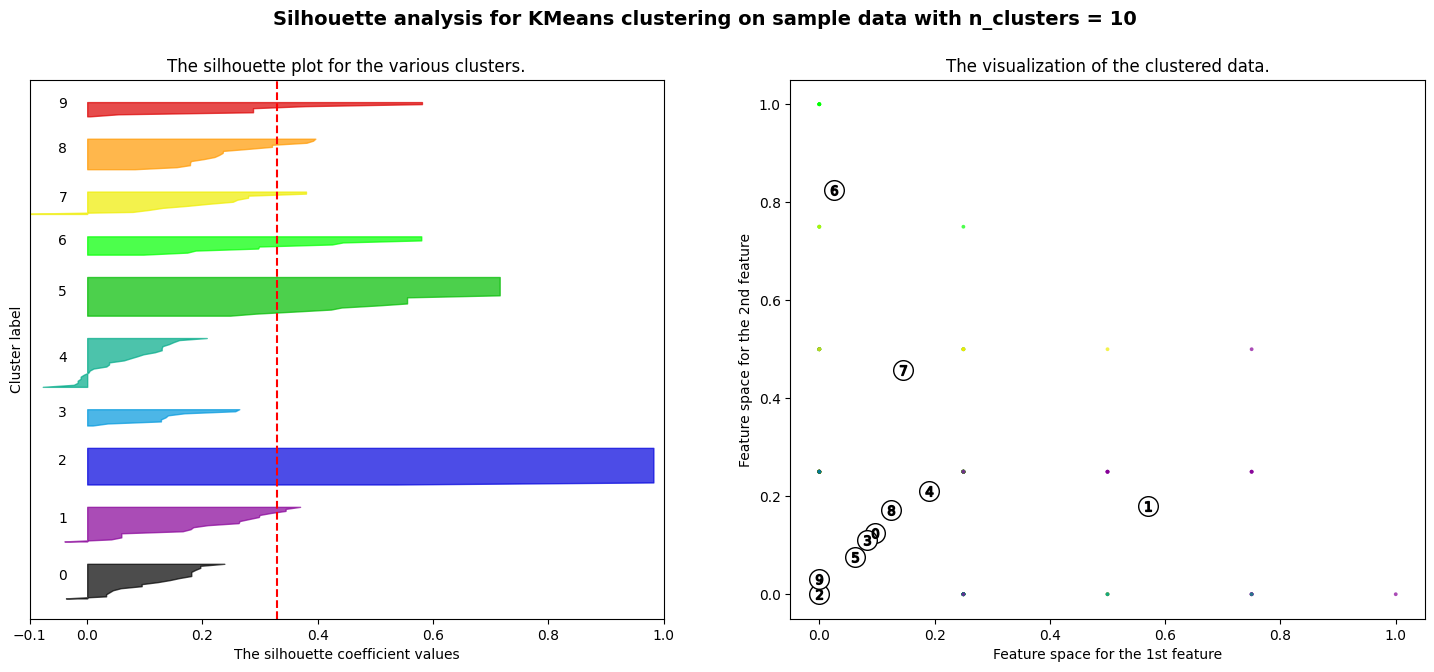

In [5]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]

X = df_subset.to_numpy()

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

In [6]:
df_subset_columns =df_subset.columns
df_subset_max=df_subset.max(axis=1)
for x in df_subset_columns:
    n_rows = sum(df_subset[x]>=df_subset_max)
    print(f"{n_rows } entries reporting this funding source as highest or tied-for-highest support percentage:\n {x}")

21 entries reporting this funding source as highest or tied-for-highest support percentage:
 grants (mine)
27 entries reporting this funding source as highest or tied-for-highest support percentage:
 grants (others')
75 entries reporting this funding source as highest or tied-for-highest support percentage:
 internal
8 entries reporting this funding source as highest or tied-for-highest support percentage:
 consulting
18 entries reporting this funding source as highest or tied-for-highest support percentage:
 analysis projects
52 entries reporting this funding source as highest or tied-for-highest support percentage:
 microscope fees
24 entries reporting this funding source as highest or tied-for-highest support percentage:
 I don't know
